<a href="https://colab.research.google.com/github/ChristianAgyapong/Medgemma/blob/main/TASK_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import the tools we need**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

**Load the dataset ( no CSV needed)**

In [ ]:
iris = load_iris(as_frame=True)   # gives us pandas DataFrame
df = iris.frame

print("Shape:", df.shape)
print("\nColumns (features + target):")
print(df.columns.tolist())

print("\nTarget classes (species):")
print(iris.target_names)   # ['setosa', 'versicolor', 'virginica']

# Quick look
print("\nFirst 5 rows:")
print(df.head())

Shape: (150, 5)

Columns (features + target):
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']

Target classes (species):
['setosa' 'versicolor' 'virginica']

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


**Prepare X (features) and y (target)**

In [ ]:
X = df.drop('target', axis=1)   # all 4 measurements
y = df['target']                # 0,1,2 for the 3 species

print("Features shape:", X.shape)
print("Target shape :", y.shape)

Features shape: (150, 4)
Target shape : (150,)


**Split into train + test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,          # 30% test – common for small dataset like Iris
    random_state=42,
    stratify=y              # keeps same % of each species in train & test
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size: 105
Test size : 45


**Change words (categories) to numbers**

In [ ]:
# Create model with 5 nearest neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# Train it
knn.fit(X_train, y_train)

print("KNN model (k=5) trained! ✓")

KNN model (k=5) trained! ✓


**Scale (make numbers similar size) – Age and Fare only**

In [ ]:
y_pred = knn.predict(X_test)

# Simple accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy with k=5: {acc:.3f} → {acc*100:.1f}% correct")

Accuracy with k=5: 0.978 → 97.8% correct


**Separate features (X) and target (y)**

Confusion Matrix:
[[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]


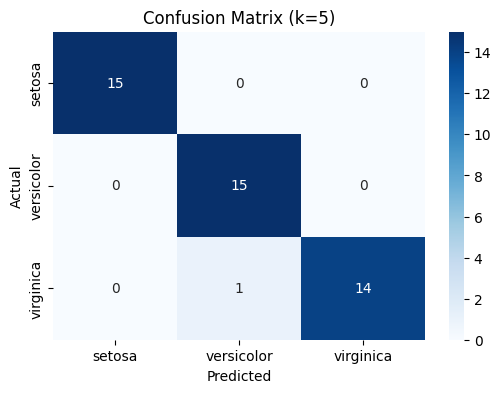

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Nice visual
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (k=5)')
plt.show()

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [ ]:
k_values = [1, 3, 5, 7, 9, 11, 15]
accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_test)
    acc_temp = accuracy_score(y_test, y_pred_temp)
    accuracies.append(acc_temp)
    print(f"k={k:2d} → Accuracy: {acc_temp:.3f}")

# Find best k
best_k = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f"\nBest k: {best_k} with accuracy {best_acc:.3f}")

k= 1 → Accuracy: 0.933
k= 3 → Accuracy: 0.956
k= 5 → Accuracy: 0.978
k= 7 → Accuracy: 0.956
k= 9 → Accuracy: 0.956
k=11 → Accuracy: 0.933
k=15 → Accuracy: 0.956

Best k: 5 with accuracy 0.978


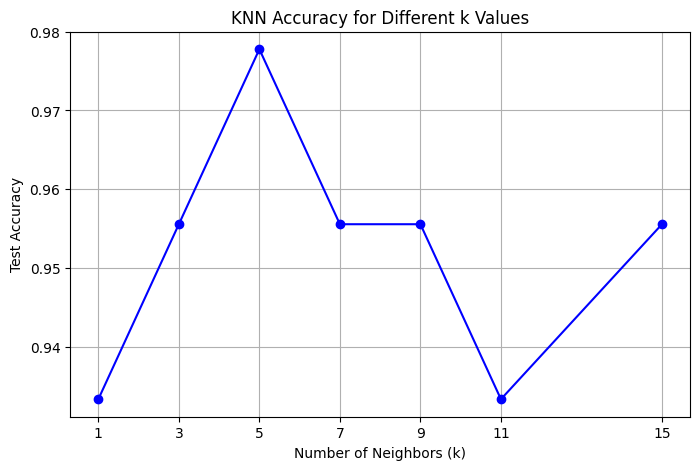

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Accuracy')
plt.title('KNN Accuracy for Different k Values')
plt.grid(True)
plt.xticks(k_values)
plt.show()